In [90]:
print("Define Wirecell Energy Cuts")

# read input and create arrays
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
import sys
import os
from scipy.spatial import KDTree

Define Wirecell Energy Cuts


In [91]:
# Lets define all initial variables we want to use to read all files
first_event               = 0     # first event number in the list of all events
last_event                = 12    # last event number in the list of all events
evt                       = 3     # event number for showing an example

SBNDCODE_VERSION          = "v10_06_00"   # Use the latest version available
PROCESS                   = "nu_spill"    # options: "nu_spill", "cosmic_spill"
apa                       = "APA0"        # options: "APA0", "APA1"

# Energy cuts to analyze (in MeV)
energy_cuts = [5.0, 10.0, 50.0]
apply_cut   = True

OUTDIR=Path("/exp/sbnd/data/users/prabhjot/wirecell_clustering/cluster_evaluation/runcode/")
SUBDIR="Results_MC_2viewactive_2viewdead" # Subdirectory containing data

print("SBNDCODE_VERSION:", SBNDCODE_VERSION)
print("PROCESS:", PROCESS)
print("apa:", apa)
print("OUTDIR", OUTDIR)
print("SUBDIR", SUBDIR)
print("First event", first_event)
print("Last event", last_event)
print("Energy cuts (MeV):", energy_cuts)
print("Apply cut:", apply_cut)

SBNDCODE_VERSION: v10_06_00
PROCESS: nu_spill
apa: APA0
OUTDIR /exp/sbnd/data/users/prabhjot/wirecell_clustering/cluster_evaluation/runcode
SUBDIR Results_MC_2viewactive_2viewdead
First event 0
Last event 12
Energy cuts (MeV): [5.0, 10.0, 50.0]
Apply cut: True


In [92]:
# Create output sub-directories

OUTDIR=OUTDIR / SUBDIR

if PROCESS == "nu_spill":
  OUTDIR = OUTDIR / SBNDCODE_VERSION / PROCESS    
elif PROCESS == "cosmics":
  OUTDIR = OUTDIR / SBNDCODE_VERSION / "cosmics"
else:
  print("\n Incorrect PROCESS.\n\n")

In [93]:
# skip notebook if missing truth files
SKIP_NOTEBOOK = False   # TODO: what does this do?

print ("Checking for required truth files...")

# helper function to skip notebook execution
def skip_if_needed():
    if globals().get("SKIP_NOTEBOOK", False):
        return True
    return False

Checking for required truth files...


In [94]:
# Definition to read true and predicted coordinates

def read_true_coordinates(files):
    """Reads coordinates from text files and returns numpy arrays."""
    _x = np.loadtxt(files[0])
    _y = np.loadtxt(files[1])
    _z = np.loadtxt(files[2])
    _id = np.loadtxt(files[3])
    _q = np.loadtxt(files[4])
    _e = np.loadtxt(files[5])
    _t = np.loadtxt(files[6])
    return _x, _y, _z, _id, _q, _e, _t

def read_pred_coordinates(files):
    """Reads coordinates from text files and returns numpy arrays."""
    _x = np.loadtxt(files[0])
    _y = np.loadtxt(files[1])
    _z = np.loadtxt(files[2])
    _id = np.loadtxt(files[3])
    _q = np.loadtxt(files[4])
    return _x, _y, _z, _id, _q

In [95]:
# Definition to point to input text file for each event

NEWOUTDIR     = OUTDIR/"xyz-coordinates"  
def files_true_pred(evt):
    fx_true_apa0  = NEWOUTDIR / str(evt) / "x_truth_apa0.txt"
    fy_true_apa0  = NEWOUTDIR / str(evt) / "y_truth_apa0.txt"
    fz_true_apa0  = NEWOUTDIR / str(evt) / "z_truth_apa0.txt"
    fq_true_apa0  = NEWOUTDIR / str(evt) / "charge_truth_apa0.txt"
    fid_true_apa0 = NEWOUTDIR / str(evt) / "clusterid_truth_apa0.txt"
    fe_true_apa0  = NEWOUTDIR / str(evt) / "energy_truth_apa0.txt"
    ft_true_apa0  = NEWOUTDIR / str(evt) / "time_truth_apa0.txt"

    fx_true_apa1  = NEWOUTDIR / str(evt) / "x_truth_apa1.txt"
    fy_true_apa1  = NEWOUTDIR / str(evt) / "y_truth_apa1.txt"
    fz_true_apa1  = NEWOUTDIR / str(evt) / "z_truth_apa1.txt"
    fq_true_apa1  = NEWOUTDIR / str(evt) / "charge_truth_apa1.txt"
    fid_true_apa1 = NEWOUTDIR / str(evt) / "clusterid_truth_apa1.txt"
    fe_true_apa1  = NEWOUTDIR / str(evt) / "energy_truth_apa1.txt"
    ft_true_apa1  = NEWOUTDIR / str(evt) / "time_truth_apa1.txt"

    fx_pred_apa0  = NEWOUTDIR / str(evt) / "x_clustering_apa0.txt"
    fy_pred_apa0  = NEWOUTDIR / str(evt) / "y_clustering_apa0.txt"
    fz_pred_apa0  = NEWOUTDIR / str(evt) / "z_clustering_apa0.txt"
    fq_pred_apa0  = NEWOUTDIR / str(evt) / "charge_clustering_apa0.txt"
    fid_pred_apa0 = NEWOUTDIR / str(evt) / "clusterid_clustering_apa0.txt"

    fx_pred_apa1  = NEWOUTDIR / str(evt) / "x_clustering_apa1.txt"
    fy_pred_apa1  = NEWOUTDIR / str(evt) / "y_clustering_apa1.txt"
    fz_pred_apa1  = NEWOUTDIR / str(evt) / "z_clustering_apa1.txt"
    fq_pred_apa1  = NEWOUTDIR / str(evt) / "charge_clustering_apa1.txt"
    fid_pred_apa1 = NEWOUTDIR / str(evt) / "clusterid_clustering_apa1.txt"

    # check for missing or empty truth files
    if apa =='APA0':
        if not fx_true_apa0.exists() or os.stat(fx_true_apa0).st_size <= 1:
            print(f"{fx_true_apa0} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fy_true_apa0.exists() or os.stat(fy_true_apa0).st_size<= 1:
            print(f"{fy_true_apa0} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fz_true_apa0.exists() or os.stat(fz_true_apa0).st_size <= 1:
            print(f"{fz_true_apa0} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fx_pred_apa0.exists() or os.stat(fx_pred_apa0).st_size <= 1:
            print(f"{fx_pred_apa0} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fy_pred_apa0.exists() or os.stat(fy_pred_apa0).st_size<= 1:
            print(f"{fy_pred_apa0} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fz_pred_apa0.exists() or os.stat(fz_pred_apa0).st_size <= 1:
            print(f"{fz_pred_apa0} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
    elif apa =='APA1':
        if not fx_true_apa1.exists() or os.stat(fx_true_apa1).st_size <= 1:
            print(f"{fx_true_apa1} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fy_true_apa1.exists() or os.stat(fy_true_apa1).st_size <= 1:
            print(f"{fy_true_apa1} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fz_true_apa1.exists() or os.stat(fz_true_apa1).st_size <= 1:
            print(f"{fz_true_apa1} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fx_pred_apa1.exists() or os.stat(fx_pred_apa1).st_size <= 1:
            print(f"{fx_pred_apa1} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fy_pred_apa1.exists() or os.stat(fy_pred_apa1).st_size<= 1:
            print(f"{fy_pred_apa1} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
        if not fz_pred_apa1.exists() or os.stat(fz_pred_apa1).st_size <= 1:
            print(f"{fz_pred_apa1} not found or empty. Skipping rest of notebook.")
            SKIP_NOTEBOOK = True
    else:
        print("Incorrect apa.")
        
    # Skip if truth files not found
    if skip_if_needed():
        print("Skipping this cell.")
    else:
        
        # group files for loading
        true_files_apa0 = [fx_true_apa0, fy_true_apa0, fz_true_apa0, fid_true_apa0, fq_true_apa0, fe_true_apa0, ft_true_apa0]  # Replace with file names
        true_files_apa1 = [fx_true_apa1, fy_true_apa1, fz_true_apa1, fid_true_apa1, fq_true_apa1, fe_true_apa1, ft_true_apa1]  # Replace with file names
        pred_files_apa0 = [fx_pred_apa0, fy_pred_apa0, fz_pred_apa0, fid_pred_apa0, fq_pred_apa0]
        pred_files_apa1 = [fx_pred_apa1, fy_pred_apa1, fz_pred_apa1, fid_pred_apa1, fq_pred_apa1]

        if apa =='APA0':
            true_files = true_files_apa0
            reco_files = pred_files_apa0
        else:
            true_files = true_files_apa1
            reco_files = pred_files_apa1
    return true_files, reco_files

In [96]:
# Now we get the variable values

# loop over many events to read all variables for all events
all_events_true_x = []
all_events_true_y = []
all_events_true_z = []
all_events_true_id = []
all_events_true_q = []
all_events_true_e = []
all_events_true_t = []

all_events_reco_x = []
all_events_reco_y = []
all_events_reco_z = []
all_events_reco_id = []
all_events_reco_q = []

# Lets read folders of all events
for e in range(first_event, last_event+1):
  print("Event: ", e)

  true_files, pred_files = files_true_pred(e)

  # Define placeholders
  x_true = y_true = z_true = id_true = q_true = e_true = t_true = None
  x_pred = y_pred = z_pred = id_pred = q_pred = None

  # Load the true and predicted coordinates
  if apa =='APA0':
    x_true_apa0, y_true_apa0, z_true_apa0, id_true_apa0, q_true_apa0, e_true_apa0 , t_true_apa0 = read_true_coordinates(true_files)
    x_pred_apa0, y_pred_apa0, z_pred_apa0, id_pred_apa0, q_pred_apa0                            = read_pred_coordinates(pred_files)
    
    x_true  = x_true_apa0
    y_true  = y_true_apa0
    z_true  = z_true_apa0
    id_true = id_true_apa0
    q_true  = q_true_apa0
    e_true  = e_true_apa0
    t_true  = t_true_apa0

    x_pred  = x_pred_apa0
    y_pred  = y_pred_apa0
    z_pred  = z_pred_apa0
    id_pred = id_pred_apa0
    q_pred  = q_pred_apa0

  elif apa =='APA1':
    x_true_apa1, y_true_apa1, z_true_apa1, id_true_apa1, q_true_apa1, e_true_apa1, t_true_apa1= read_true_coordinates(true_files)
    x_pred_apa1, y_pred_apa1, z_pred_apa1, id_pred_apa1, q_pred_apa1                          = read_pred_coordinates(pred_files)
    
    x_true  = x_true_apa1
    y_true  = y_true_apa1
    z_true  = z_true_apa1
    id_true = id_true_apa1
    q_true  = q_true_apa1   
    e_true  = e_true_apa1
    t_true  = t_true_apa1

    x_pred  = x_pred_apa1
    y_pred  = y_pred_apa1
    z_pred  = z_pred_apa1
    id_pred = id_pred_apa1
    q_pred  = q_pred_apa1

  else:
    print("Incorrect apa.")


  all_events_true_x.append(x_true)
  all_events_true_y.append(y_true)
  all_events_true_z.append(z_true)
  all_events_true_id.append(id_true)
  all_events_true_q.append(q_true)
  all_events_true_e.append(e_true)
  all_events_true_t.append(t_true)

  all_events_reco_x.append(x_pred)
  all_events_reco_y.append(y_pred)
  all_events_reco_z.append(z_pred)
  all_events_reco_id.append(id_pred)
  all_events_reco_q.append(q_pred)

# Function to calculate cluster energies
def calculate_all_cluster_energies(event_ids_list, event_energies_list):
    """Calculate total energy for each cluster across all events."""
    all_cluster_energies = []
    for event_idx in range(len(event_ids_list)):
        cluster_ids = event_ids_list[event_idx]
        point_energies = event_energies_list[event_idx]
        unique_ids = np.unique(cluster_ids)
        for cluster_id in unique_ids:
            mask = cluster_ids == cluster_id
            cluster_energy = np.sum(point_energies[mask])
            all_cluster_energies.append(cluster_energy)
    return np.array(all_cluster_energies)

# Calculate cluster energies for all events
all_cluster_energies = calculate_all_cluster_energies(all_events_true_id, all_events_true_e)

Event:  0
Event:  1
Event:  2
Event:  3
Event:  4
Event:  5
Event:  6
Event:  7
Event:  8
Event:  9
Event:  10
Event:  11
Event:  12


In [97]:
# Get the cluster energy statistics
print("Cluster energy statistics:")
print(f"  Total clusters: {len(all_cluster_energies)}")
print(f"  Energy range: {all_cluster_energies.min():.2f} - {all_cluster_energies.max():.2f} MeV")
print(f"  Mean energy: {all_cluster_energies.mean():.2f} MeV")
print(f"  Median energy: {np.median(all_cluster_energies):.2f} MeV")

Cluster energy statistics:
  Total clusters: 344
  Energy range: 0.09 - 1468.89 MeV
  Mean energy: 78.70 MeV
  Median energy: 1.48 MeV


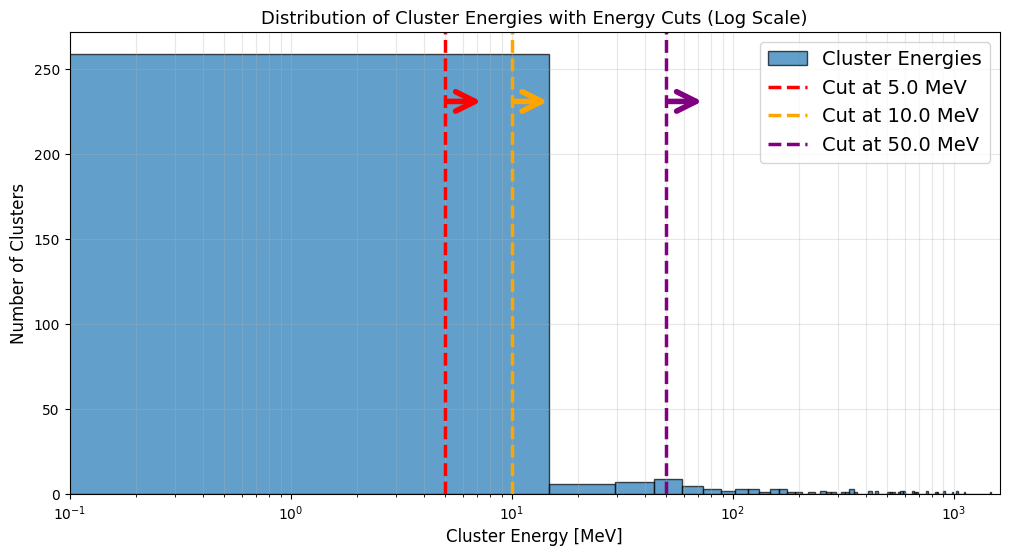


Cluster Energy Cut Statistics:
  5.0 MeV: 108 clusters kept (31.4%), 236 removed
  10.0 MeV: 89 clusters kept (25.9%), 255 removed
  50.0 MeV: 68 clusters kept (19.8%), 276 removed


In [98]:
# Plot the full cluster energy distribution with cut lines
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(all_cluster_energies, bins=100, edgecolor='black', alpha=0.7, label='Cluster Energies')

# Draw energy cut lines with arrows
colors = ['red', 'orange', 'purple']
for cut, color in zip(energy_cuts, colors):
    ax.axvline(cut, color=color, linestyle='--', linewidth=2.5, label=f'Cut at {cut} MeV')
    
    # Add large arrow pointing to the right (selected side)
    y_max = ax.get_ylim()[1]
    arrow_length = cut * 0.5
    ax.annotate('', xy=(cut + arrow_length, y_max * 0.85), xytext=(cut, y_max * 0.85),
                arrowprops=dict(arrowstyle='->', color=color, lw=4, mutation_scale=35))

ax.set_xlabel("Cluster Energy [MeV]", fontsize=12)
ax.set_ylabel("Number of Clusters", fontsize=12)
ax.set_title("Distribution of Cluster Energies with Energy Cuts (Log Scale)", fontsize=13)
ax.set_xscale('log')
ax.set_xlim(0.1, max(all_cluster_energies.max() * 1.1, 60))
ax.legend(fontsize=14, loc='upper right')
ax.grid(True, alpha=0.3, which='both')
plt.show(block=False)

# Print statistics for each cut
print("\nCluster Energy Cut Statistics:")
for cut in energy_cuts:
    n_above = np.sum(all_cluster_energies >= cut)
    n_below = np.sum(all_cluster_energies < cut)
    pct_kept = 100.0 * n_above / len(all_cluster_energies)
    print(f"  {cut} MeV: {n_above} clusters kept ({pct_kept:.1f}%), {n_below} removed")

In [99]:
# Get true and reco clusters for specific event
print(f"Getting true and reco clusters for event {evt}...")

# Extract data for the specific event (offset by first_event since arrays start from first_event)
event_index = evt

evt_true_x = all_events_true_x[event_index]
evt_true_y = all_events_true_y[event_index]
evt_true_z = all_events_true_z[event_index]
evt_true_id = all_events_true_id[event_index]
evt_true_q = all_events_true_q[event_index]
evt_true_e = all_events_true_e[event_index]
evt_true_t = all_events_true_t[event_index]

evt_reco_x = all_events_reco_x[event_index]
evt_reco_y = all_events_reco_y[event_index]
evt_reco_z = all_events_reco_z[event_index]
evt_reco_id = all_events_reco_id[event_index]
evt_reco_q = all_events_reco_q[event_index]

print(f"Event {evt} - True clusters: {len(evt_true_x)} points, {len(np.unique(evt_true_id))} unique cluster IDs")
print(f"Event {evt} - Reco clusters: {len(evt_reco_x)} points, {len(np.unique(evt_reco_id))} unique cluster IDs")

Getting true and reco clusters for event 3...
Event 3 - True clusters: 45974 points, 27 unique cluster IDs
Event 3 - Reco clusters: 12760 points, 41 unique cluster IDs


/tmp/ipykernel_2127653/4281045041.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20')


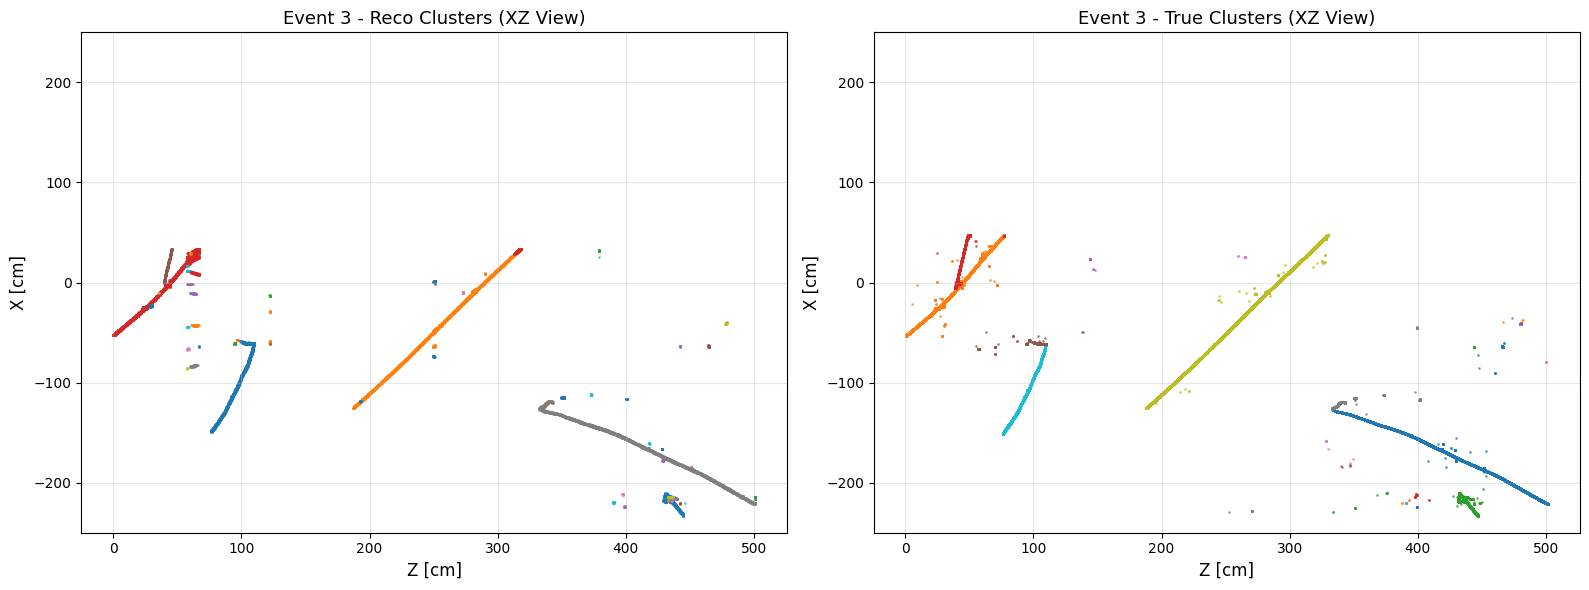

Reco plot: 41 clusters
True plot: 27 clusters


In [100]:
# Draw all clusters in XZ view - Reco (left) and True (right)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Get unique cluster IDs
unique_true_ids = np.unique(evt_true_id)
unique_reco_ids = np.unique(evt_reco_id)

# Create a colormap for consistent coloring
cmap = plt.cm.get_cmap('tab20')

# Left plot: Reco clusters
ax_reco = axes[0]
for i, cluster_id in enumerate(unique_reco_ids):
    mask = evt_reco_id == cluster_id
    ax_reco.scatter(evt_reco_z[mask], evt_reco_x[mask], 
                    s=1, alpha=0.6, label=f'Cluster {int(cluster_id)}')
ax_reco.set_xlabel('Z [cm]', fontsize=12)
ax_reco.set_ylabel('X [cm]', fontsize=12)
ax_reco.set_ylim(-250, 250)
ax_reco.set_title(f'Event {evt} - Reco Clusters (XZ View)', fontsize=13)
#ax_reco.legend(fontsize=12, loc='upper left', ncol=2)
ax_reco.grid(True, alpha=0.3)

# Right plot: True clusters
ax_true = axes[1]
for i, cluster_id in enumerate(unique_true_ids):
    mask = evt_true_id == cluster_id
    ax_true.scatter(evt_true_z[mask], evt_true_x[mask], 
                    s=1, alpha=0.6, label=f'Cluster {int(cluster_id)}')
ax_true.set_xlabel('Z [cm]', fontsize=12)
ax_true.set_ylabel('X [cm]', fontsize=12)
ax_true.set_ylim(-250, 250)
ax_true.set_title(f'Event {evt} - True Clusters (XZ View)', fontsize=13)
#ax_true.legend(fontsize=12, loc='upper left', ncol=2)
ax_true.grid(True, alpha=0.3)

plt.tight_layout()
plt.show(block=False)

print(f"Reco plot: {len(unique_reco_ids)} clusters")
print(f"True plot: {len(unique_true_ids)} clusters")

In [101]:
# Calculate cluster energies (sum of all point energies in each cluster)
def calculate_cluster_energies(cluster_ids, point_energies):
    """Calculate total energy for each cluster."""
    unique_ids = np.unique(cluster_ids)
    cluster_energies = {}
    
    for cluster_id in unique_ids:
        mask = cluster_ids == cluster_id
        cluster_energies[cluster_id] = np.sum(point_energies[mask])
    
    return cluster_energies

# Calculate energies for true clusters
true_cluster_energies = calculate_cluster_energies(evt_true_id, evt_true_e)

print("True Cluster Energies:")
for cluster_id in sorted(true_cluster_energies.keys()):
    print(f"  Cluster {int(cluster_id)}: {true_cluster_energies[cluster_id]:.2f} MeV")

True Cluster Energies:
  Cluster 10000469: 6.37 MeV
  Cluster 10000471: 0.33 MeV
  Cluster 10000484: 1.19 MeV
  Cluster 10000654: 5.52 MeV
  Cluster 10000656: 1.76 MeV
  Cluster 10000658: 6.15 MeV
  Cluster 10000865: 0.39 MeV
  Cluster 20000014: 0.87 MeV
  Cluster 20000046: 648.61 MeV
  Cluster 20000052: 338.52 MeV
  Cluster 20000113: 588.91 MeV
  Cluster 20000114: 751.79 MeV
  Cluster 20000164: 174.71 MeV
  Cluster 20000168: 154.51 MeV
  Cluster 20000190: 1.18 MeV
  Cluster 20126216: 0.59 MeV
  Cluster 20126516: 0.84 MeV
  Cluster 20275706: 39.29 MeV
  Cluster 20346486: 10.97 MeV
  Cluster 20346488: 5.17 MeV
  Cluster 20346489: 1.27 MeV
  Cluster 20346491: 0.38 MeV
  Cluster 20346766: 1.06 MeV
  Cluster 20346767: 1.91 MeV
  Cluster 20383991: 0.82 MeV
  Cluster 20444788: 45.24 MeV
  Cluster 20590997: 1.01 MeV


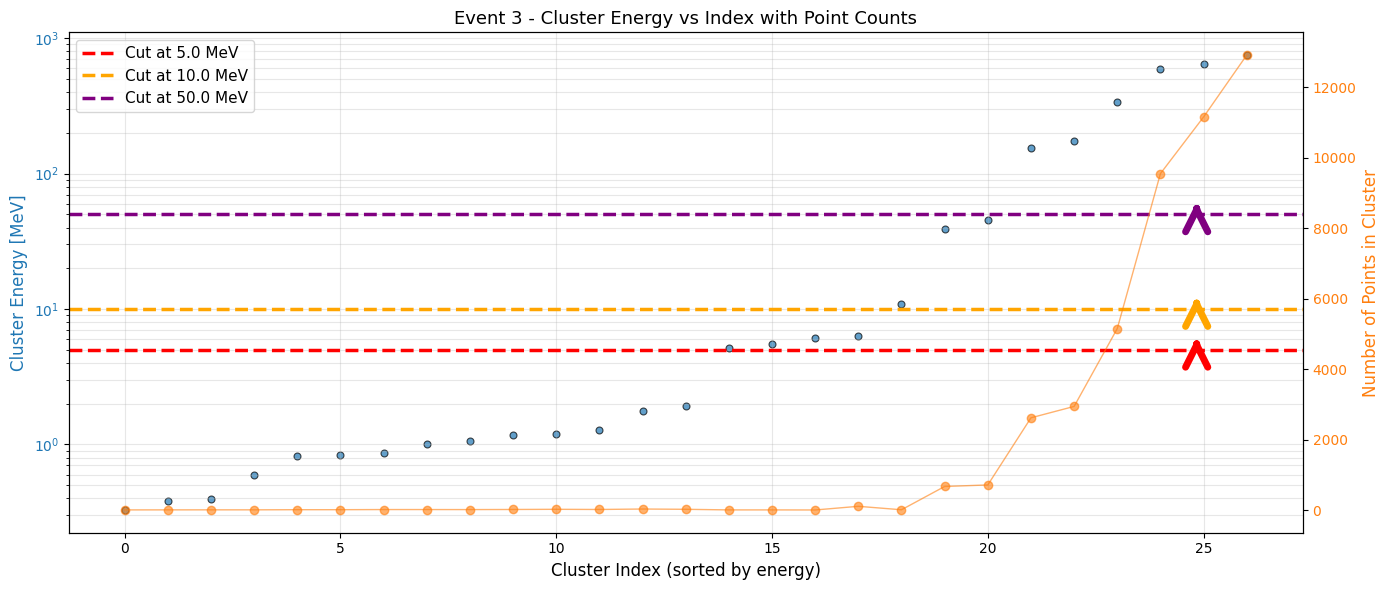


Event 3 Cluster Energy & Point Count Summary:
  Total clusters: 27
  Energy range: 0.33 - 751.79 MeV
  Point count range: 1 - 12907 points
  Mean energy: 103.31 MeV
  Median energy: 1.91 MeV


In [102]:
# Plot cluster energies for event 3 only - cluster energy vs cluster index
# Also show number of points in each cluster on secondary axis

# Sort cluster energies for event 3 visualization
sorted_cluster_ids = sorted(true_cluster_energies.keys(), key=lambda x: true_cluster_energies[x])
sorted_energies_evt = np.array([true_cluster_energies[cid] for cid in sorted_cluster_ids])
cluster_indices_evt = np.arange(len(sorted_energies_evt))

# Calculate number of points in each cluster
cluster_point_counts = {}
for cluster_id in sorted_cluster_ids:
    mask = evt_true_id == cluster_id
    cluster_point_counts[cluster_id] = np.sum(mask)
sorted_point_counts = np.array([cluster_point_counts[cid] for cid in sorted_cluster_ids])

# Plot cluster energies vs cluster index with dual y-axes
fig, ax1 = plt.subplots(figsize=(14, 6))

# Left y-axis: Cluster energy
color = 'tab:blue'
ax1.set_xlabel("Cluster Index (sorted by energy)", fontsize=12)
ax1.set_ylabel("Cluster Energy [MeV]", fontsize=12, color=color)
ax1.scatter(cluster_indices_evt, sorted_energies_evt, s=25, alpha=0.7, c=color, edgecolors='black', linewidth=0.8)
ax1.set_yscale('log')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3, which='both')

# Right y-axis: Number of points
ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel("Number of Points in Cluster", fontsize=12, color=color)
ax2.plot(cluster_indices_evt, sorted_point_counts, 'o-', color=color, alpha=0.6, markersize=6, linewidth=1)
ax2.tick_params(axis='y', labelcolor=color)

# Draw horizontal lines for energy cuts on left axis with LARGE arrows
colors = ['red', 'orange', 'purple']
for cut, color in zip(energy_cuts, colors):
    ax1.axhline(cut, color=color, linestyle='--', linewidth=2.5, label=f'Cut at {cut} MeV')
    # Add LARGE arrow pointing upward (to show which side is selected)
    arrow_height = cut * 0.3
    ax1.annotate('', xy=(len(sorted_energies_evt) * 0.92, cut + arrow_height), 
                xytext=(len(sorted_energies_evt) * 0.92, cut),
                arrowprops=dict(arrowstyle='->', color=color, lw=5, mutation_scale=40))

ax1.set_title(f"Event {evt} - Cluster Energy vs Index with Point Counts", fontsize=13)
ax1.legend(fontsize=11, loc='upper left')
fig.tight_layout()
plt.show(block=False)

print(f"\nEvent {evt} Cluster Energy & Point Count Summary:")
print(f"  Total clusters: {len(true_cluster_energies)}")
print(f"  Energy range: {min(true_cluster_energies.values()):.2f} - {max(true_cluster_energies.values()):.2f} MeV")
print(f"  Point count range: {min(cluster_point_counts.values())} - {max(cluster_point_counts.values())} points")
print(f"  Mean energy: {np.mean(sorted_energies_evt):.2f} MeV")
print(f"  Median energy: {np.median(sorted_energies_evt):.2f} MeV")

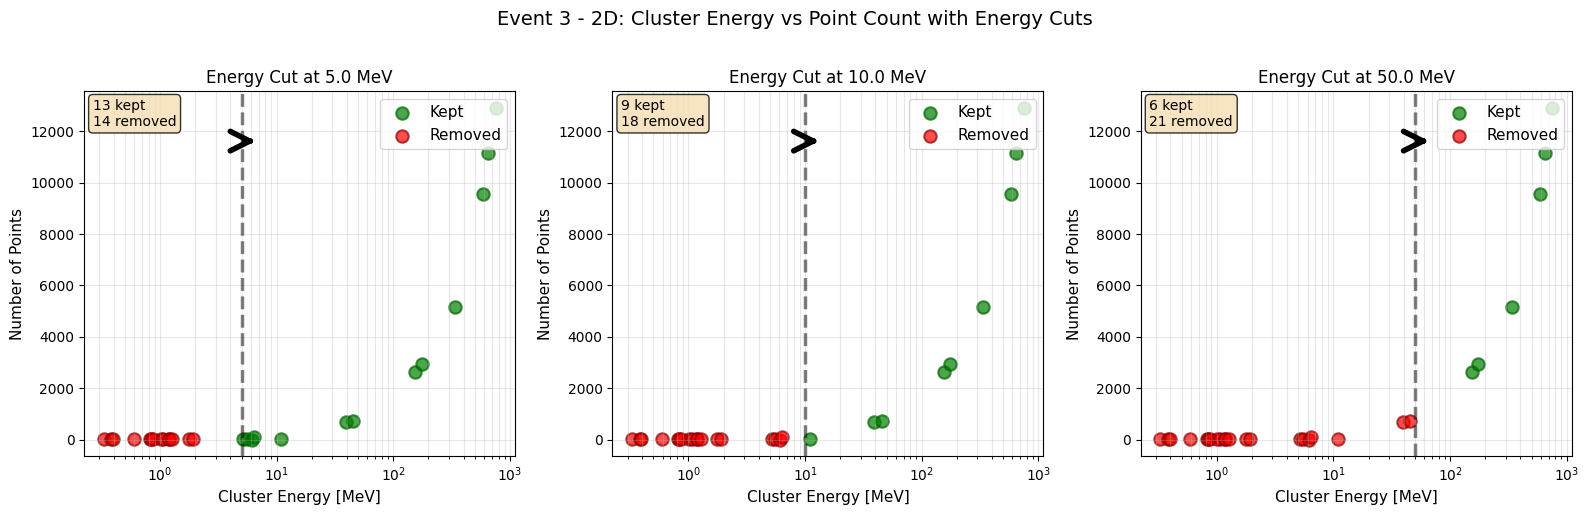

In [103]:
# 2D plot: Cluster energy vs number of points with cut indicators
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

cluster_energies_list = np.array([true_cluster_energies[cid] for cid in sorted_cluster_ids])
point_counts_list = np.array([cluster_point_counts[cid] for cid in sorted_cluster_ids])

# Define a helper function to mark removed clusters
def passes_energy_cut(cluster_energy, cut_threshold):
    return cluster_energy >= cut_threshold

for cut_idx, energy_cut in enumerate(energy_cuts):
    ax = axes[cut_idx]
    
    # Determine which clusters pass the cut
    clusters_pass = np.array([passes_energy_cut(e, energy_cut) if apply_cut else True for e in cluster_energies_list])
    
    # Plot kept clusters (green)
    kept_mask = clusters_pass
    ax.scatter(cluster_energies_list[kept_mask], point_counts_list[kept_mask], 
              s=80, alpha=0.7, c='green', edgecolors='darkgreen', linewidth=1.5, label='Kept')
    
    # Plot removed clusters (red)
    removed_mask = ~clusters_pass
    ax.scatter(cluster_energies_list[removed_mask], point_counts_list[removed_mask], 
              s=80, alpha=0.7, c='red', edgecolors='darkred', linewidth=1.5, label='Removed')
    
    # Draw vertical line at energy cut with LARGE arrow
    ax.axvline(energy_cut, color='black', linestyle='--', linewidth=2.5, alpha=0.5)
    
    # Add LARGE arrow pointing to the right
    y_range = point_counts_list.max() - point_counts_list.min()
    arrow_length = energy_cut * 0.4
    ax.annotate('', xy=(energy_cut + arrow_length, point_counts_list.max() * 0.9), 
               xytext=(energy_cut, point_counts_list.max() * 0.9),
               arrowprops=dict(arrowstyle='->', color='black', lw=4, mutation_scale=35))
    
    ax.set_xlabel("Cluster Energy [MeV]", fontsize=11)
    ax.set_ylabel("Number of Points", fontsize=11)
    ax.set_title(f"Energy Cut at {energy_cut} MeV", fontsize=12)
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3, which='both')
    ax.legend(fontsize=11, loc='upper right')
    
    # Count and display statistics
    n_kept = np.sum(kept_mask)
    n_removed = np.sum(removed_mask)
    ax.text(0.02, 0.98, f'{n_kept} kept\n{n_removed} removed', 
           transform=ax.transAxes, fontsize=10, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

fig.suptitle(f"Event {evt} - 2D: Cluster Energy vs Point Count with Energy Cuts", fontsize=14, y=1.02)
plt.tight_layout()
plt.show(block=False)

/tmp/ipykernel_2127653/2793726952.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20')


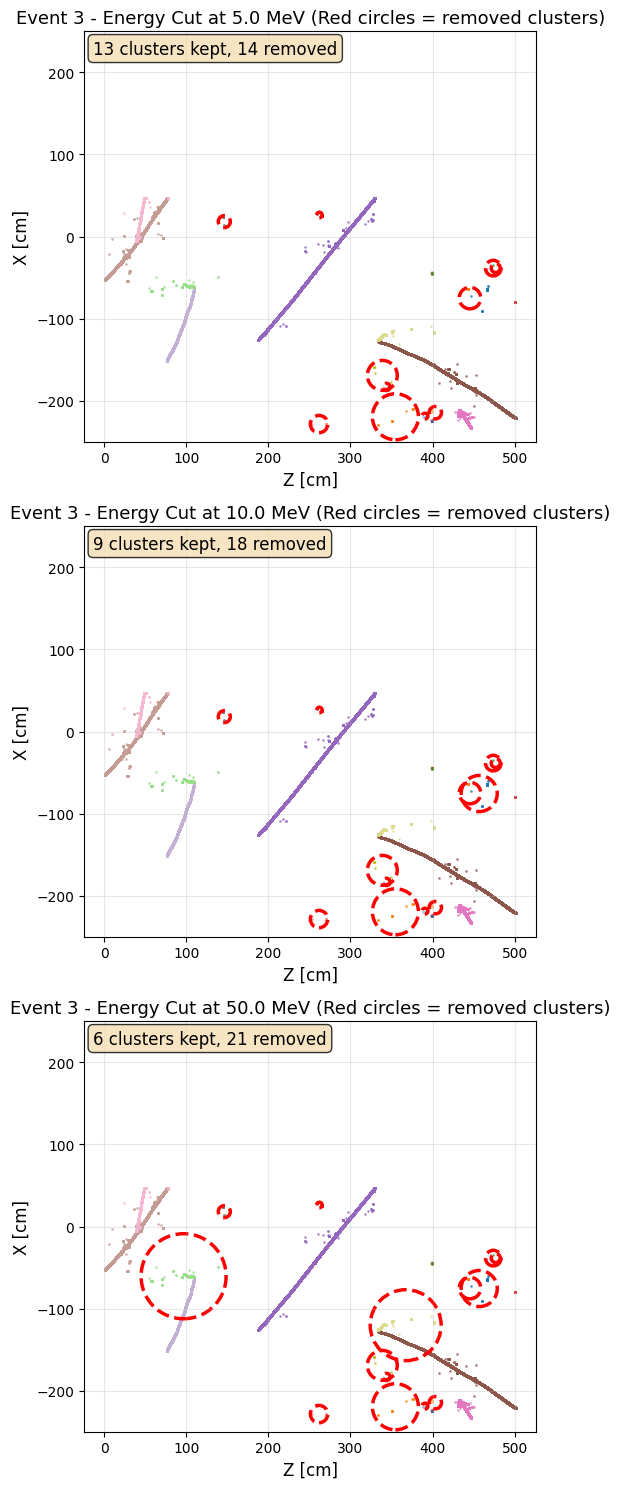

In [104]:
# Define energy cut function
def passes_energy_cut(cluster_energy, cut_threshold):
    """Check if cluster passes energy cut."""
    return cluster_energy >= cut_threshold

# Show which clusters pass/fail each energy cut
fig, axes = plt.subplots(len(energy_cuts), 1, figsize=(14, 5*len(energy_cuts)))
if len(energy_cuts) == 1:
    axes = [axes]

unique_true_ids = np.unique(evt_true_id)

# Create a colormap for consistent cluster coloring
cmap = plt.cm.get_cmap('tab20')

for cut_idx, energy_cut in enumerate(energy_cuts):
    ax = axes[cut_idx]
    
    # Determine which clusters pass the cut
    clusters_above_cut = {}
    for cluster_id in unique_true_ids:
        if apply_cut:
            clusters_above_cut[cluster_id] = passes_energy_cut(true_cluster_energies[cluster_id], energy_cut)
        else:
            clusters_above_cut[cluster_id] = True
    
    # Plot all clusters with their original colors
    for i, cluster_id in enumerate(unique_true_ids):
        mask = evt_true_id == cluster_id
        color = cmap(i % 20)
        ax.scatter(evt_true_z[mask], evt_true_x[mask], s=1, alpha=0.6, c=[color])
    
    # Draw circles around removed clusters
    for cluster_id in unique_true_ids:
        if not clusters_above_cut[cluster_id]:
            mask = evt_true_id == cluster_id
            z_points = evt_true_z[mask]
            x_points = evt_true_x[mask]
            
            # Calculate circle center and radius to enclose cluster
            z_center = (z_points.max() + z_points.min()) / 2
            x_center = (x_points.max() + x_points.min()) / 2
            z_range = (z_points.max() - z_points.min()) / 2
            x_range = (x_points.max() - x_points.min()) / 2
            radius = np.sqrt(z_range**2 + x_range**2) * 1.2
            
            # Draw circle
            circle = plt.Circle((z_center, x_center), radius, color='red', fill=False, linewidth=2.5, linestyle='--')
            ax.add_patch(circle)
    
    ax.set_xlabel('Z [cm]', fontsize=12)
    ax.set_ylabel('X [cm]', fontsize=12)
    ax.set_ylim(-250, 250)
    ax.set_title(f'Event {evt} - Energy Cut at {energy_cut} MeV (Red circles = removed clusters)', fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')
    
    # Count clusters above and below cut
    n_above = sum(1 for c in clusters_above_cut.values() if c)
    n_below = sum(1 for c in clusters_above_cut.values() if not c)
    ax.text(0.02, 0.98, f'{n_above} clusters kept, {n_below} removed', 
           transform=ax.transAxes, fontsize=12, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show(block=False)